In [27]:
pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.7/781.7 kB 46.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/jupyter/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /home/jupyter/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [75]:
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import warnings
warnings.simplefilter('ignore')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jupyter/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [46]:
pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 92.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [47]:
from textstat import flesch_reading_ease

In [2]:
df = pd.read_parquet('bru_merged.parquet')

In [3]:
df.shape

(2643246, 65)

In [4]:
col_to_drop = ['friends', 'fans', 'compliment_hot', 'compliment_more', 'business_working_hours',
       'compliment_profile', 'compliment_cute', 'compliment_list',
       'compliment_note', 'compliment_plain', 'compliment_cool',
       'compliment_funny', 'compliment_writer', 'compliment_photos']

In [5]:
df.drop(col_to_drop, axis = 1, inplace = True)

In [6]:
df.shape

(2643246, 51)

In [7]:
df['elite_member'] = np.where(df['elite'] == df['review_year'], 'yes', 'no')

In [8]:
df_final = df[(df['review_year'] != '2016') & (df['review_year'] != '2022')]

1. Do elite users leave higher or lower average ratings compared to non-elite users?

Comparing the Means of Two Groups: Elite vs. Non-Elite Ratings Using a t-Test
When we compare the average review ratings given by elite and non-elite users, our goal is to determine if there is a statistically significant difference in their ratings. The best approach for this is a t-test for independent samples (also called an independent t-test).

A t-test helps compare the means of two independent groups to see if the difference between them is statistically significant. In this case:

Group 1: Elite users' review ratings
Group 2: Non-elite users' review ratings
The t-test answers:
"Do elite users leave significantly higher (or lower) ratings than non-elite users?"

Our sample size is large enough to pass the Central Limit theorem assumptions


Define the Hypothesis
Null Hypothesis (H₀): There is no significant difference between the average ratings given by elite and non-elite users.
Alternative Hypothesis (H₁): Elite users give significantly higher or lower ratings than non-elite users.


If p-value < 0.05, the difference is statistically significant.
If p-value > 0.05, there's no strong evidence that elite users rate differently from non-elite users.



In [57]:
from scipy.stats import ttest_ind

# Separate elite and non-elite ratings
elite_ratings = df_final[df_final["elite_member"] == "yes"]["reviews_star_rating"]
non_elite_ratings = df_final[df_final["elite_member"] == "no"]["reviews_star_rating"]

# Perform an independent t-test
t_stat, p_value = ttest_ind(elite_ratings, non_elite_ratings, equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")


T-statistic: 187.4845, P-value: 0.0000


In [58]:
elite_ratings.mean()

4.095143774215928

In [61]:
non_elite_ratings.mean()

3.7756328436032525

Elite users tend to leave higher ratings than non-elite users, indicating they may be more positive or selective in their reviews.

This suggests that elite users may have a more positive reviewing behavior, possibly due to their experience, engagement with the platform, or selective approach in choosing businesses to review

2. How does the volume of elite user reviews correlate with a restaurant’s visibility 
(e.g., review count, rating trends, and popularity)?

Lets answer this question in two steps

In the first step, we will check whether elite reviews are correlated with restaurant visibility by calculating pearson correlation.

We calculate three variables to answer this question

1. Total number of reviews per business_id

2. Total number of elite reviews per buisness_id

3. Average ratings per business id

In [67]:
# Filter reviews from elite users
elite_reviews = df_final[df_final['elite_member'] == 'yes']

# Count elite reviews for each restaurant
business_elite_counts = elite_reviews.groupby('business_id')['review_id'].count().reset_index()

business_elite_counts.rename(columns={'review_id': 'elite_review_count'}, inplace=True)

In [71]:
# total review count
total_review_counts = df_final.groupby('business_id')['review_id'].count().reset_index()

total_review_counts.rename(columns={'review_id': 'total_review_count'}, inplace=True)

In [73]:
# average ratings per restaurant

average_rating = df_final.groupby('business_id')['reviews_star_rating'].mean().reset_index()
average_rating.rename(columns={'reviews_star_rating': 'average_rating'}, inplace=True)

In [76]:
## merge the fields
dataframes = [business_elite_counts,total_review_counts,average_rating]

correlations = reduce(lambda  left,right: pd.merge(left,right,on=['business_id'],
                                            how='inner'), dataframes)

In [80]:
correlations[['elite_review_count', 'total_review_count']].corr(method='pearson')

,elite_review_count,total_review_count
elite_review_count,1.000000,0.933607
total_review_count,0.933607,1.000000


Positive correlation (r > 0.5) → More elite reviews increase restaurant visibility.

In [79]:
import statsmodels.api as sm

X = correlations[['elite_review_count']]  # Independent variable
y = correlations['total_review_count']  # Dependent variable (restaurant visibility)

X = sm.add_constant(X)  # Add intercept
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     total_review_count   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                 2.530e+05
Date:                Sun, 16 Mar 2025   Prob (F-statistic):               0.00
Time:                        03:13:39   Log-Likelihood:            -1.9509e+05
No. Observations:               37261   AIC:                         3.902e+05
Df Residuals:                   37259   BIC:                         3.902e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 10.4446      0

Positive coefficient for elite_review_count → More elite reviews increase restaurant visibility.<br>

High R² → Strong explanatory power <br>

p-value < 0.05 → Statistically significant relationship.

There is a strong positive correlation between elite reviews and restaurant visibility,
indicating that restaurants with more elite reviews tend to have higher review counts and overall popularity.

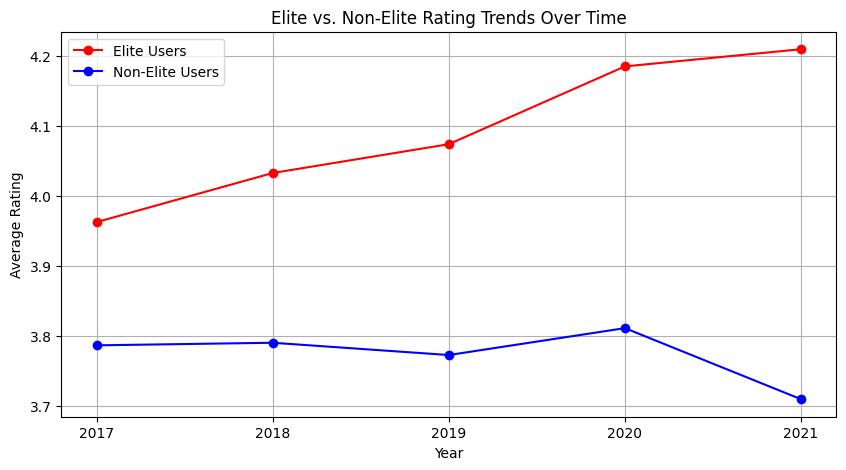

In [87]:
# Separate elite and non-elite reviews
elite_reviews = df_final[df_final['elite_member'] == 'yes']
non_elite_reviews = df_final[df_final['elite_member'] != 'yes']

# Aggregate by year
elite_avg = elite_reviews.groupby(elite_reviews['date'].dt.year)['reviews_star_rating'].mean()
non_elite_avg = non_elite_reviews.groupby(non_elite_reviews['date'].dt.year)['reviews_star_rating'].mean()

# Plot both trends
plt.figure(figsize=(10,5))
plt.plot(elite_avg.index, elite_avg.values, marker='o', linestyle='-', label='Elite Users', color='r')
plt.plot(non_elite_avg.index, non_elite_avg.values, marker='o', linestyle='-', label='Non-Elite Users', color='b')

plt.title("Elite vs. Non-Elite Rating Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.legend()
plt.grid()

# Ensure only integer years appear on the x-axis
plt.xticks(elite_avg.index.union(non_elite_avg.index))  # Sets ticks to available years

plt.show()

Segmenting ratings between elite and non-elite Yelp users helps answer key questions about reviewer behavior, bias, and the impact of elite status on restaurant ratings

Elite users might rate restaurants differently from non-elite users due to their higher engagement, experience, and expectations. We analyze rating trends to see:

Do elite users leave higher or lower ratings compared to non-elite users?
Are elite ratings more stable, or do they fluctuate over time?

Impact on Restaurant Perception
Restaurants might be affected differently depending on who reviews them:

If elite reviews are more positive, restaurants might actively seek elite customers to boost their ratings.
If elite reviews are more critical, restaurants may struggle to maintain high ratings despite good non-elite reviews.
If elite users rate more frequently, their influence on a restaurant’s overall rating could be disproportionate.
How It Helps Restaurants:
Businesses can adjust their service strategy based on the rating behavior of elite vs. non-elite users.
Restaurants can incentivize elite reviews if elite users boost ratings.
If elite users are more critical, restaurants can take steps to meet higher standards.

Yelp’s Elite Program: Does It Matter?
Yelp promotes the Elite Squad as a prestigious status. But does it actually influence review patterns?
By analyzing the trend, we answer:

Are elite reviews different because of their status, or just because they review more often?
Do elite users have an outsize impact on Yelp’s restaurant rankings?
Does the Yelp algorithm favor elite reviews more than non-elite ones?
Potential Findings:
If elite users consistently rate higher, Yelp's elite program might promote positive bias.
If elite users rate lower, Yelp’s elite status might attract harsher critics.
If non-elite ratings fluctuate while elite ratings stay more stable, elite reviews may carry greater reliability.

3.	Are elite users' reviews perceived as more useful (measured by "useful" votes) than non-elite users' reviews?

In [9]:
df_final.columns

Index(['business_id', 'business_category', 'business_name', 'city_x',
       'state_x', 'business_star_rating', 'review_count_x', 'is_open_x',
       'ByAppointmentOnly', 'BusinessAcceptsCreditCards', 'CoatCheck',
       'RestaurantsTakeOut', 'RestaurantsDelivery', 'Caters', 'WiFi',
       'WheelchairAccessible', 'HappyHour', 'OutdoorSeating', 'HasTV',
       'RestaurantsReservations', 'DogsAllowed', 'Alcohol', 'GoodForKids',
       'RestaurantsTableService', 'RestaurantsGoodForGroups', 'DriveThru',
       'NoiseLevel', 'Smoking', 'Corkage', 'MusicCategory', 'AmbienceCategory',
       'parking_final', 'text', 'reviews_received_cool', 'reviews_star_rating',
       'date', 'reviews_received_funny', 'review_id',
       'reviews_received_useful', 'user_id', 'review_year', 'name',
       'review_count', 'yelping_since', 'user_sent_useful', 'user_sent_funny',
       'user_sent_cool', 'elite', 'average_stars', 'yelping_end_year',
       'yelping_start_year', 'elite_member'],
      dtype='obje

To formally test whether elite users' reviews are perceived as more useful:

Hypothesis Testing (t-test)
Perform an independent t-test:

Null Hypothesis (H₀): There is no difference in useful votes between elite and non-elite users' reviews<br>

Alternative Hypothesis (H₁): Elite users' reviews receive more useful votes on average


In [10]:
from scipy.stats import ttest_ind

elite_votes = df_final[df_final['elite_member'] == 'yes']['reviews_received_useful']
non_elite_votes = df_final[df_final['elite_member'] == 'no']['reviews_received_useful']

t_stat, p_value = ttest_ind(elite_votes, non_elite_votes, equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

T-statistic: 285.2833, P-value: 0.0000


1. T-Statistic:

The t-statistic measures the size of the difference relative to the variation in your sample data. A large absolute t-value indicates that the observed difference is unlikely to have occurred by random chance. In your case, a t-statistic of 285.2833 is exceptionally large, suggesting a substantial difference between the two groups.

2. P-Value:

The p-value represents the probability of obtaining test results at least as extreme as the observed results, assuming that the null hypothesis is true. A p-value of 0.0000 (often reported as <0.0001) indicates that such an extreme result is highly unlikely under the null hypothesis. This leads to the rejection of the null hypothesis in favor of the alternative hypothesis.

Conclusion:

Given the extremely high t-statistic and the p-value effectively at zero, you can reject the null hypothesis with high confidence. This means there is a statistically significant difference in the number of "useful" votes between elite and non-elite users' reviews. Specifically, elite users' reviews are perceived as more useful, as measured by the number of "useful" votes.

In [21]:
def clean_text(text):
    """
    Clean and preprocess app descriptions
    """
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove special characters and digits
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def remove_stopwords(text):
    """
    Remove stopwords from text
    """
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

In [30]:
# Clean descriptions
df_final['cleaned_desc'] = df_final['text'].apply(clean_text)

In [32]:
df_final['cleaned_desc'] = df_final['text'].apply(remove_stopwords)

Textual Content Analysis

1️⃣ Compare Review Length

In [35]:
df_final['review_length'] = df_final['cleaned_desc'].apply(lambda x: len(x.split()))

elite_length = df_final[df_final['elite_member'] == 'yes']['review_length']
non_elite_length = df_final[df_final['elite_member'] == 'no']['review_length']

t_stat, p_value = ttest_ind(elite_length, non_elite_length, equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

T-statistic: 457.6556, P-value: 0.0000


Interpretation:
P-value = 0.0000 (p < 0.05)

This indicates that there is a statistically significant difference in review length between elite and non-elite users.
The probability of this difference occurring by random chance is effectively zero.
T-statistic = 457.6556 (Large Positive Value)

A very high T-statistic suggests that the mean review length for elite users is substantially different from that of non-elite users.
If the mean review length for elite users is higher, it means elite users tend to write longer reviews.
If the mean review length for elite users is lower, it means they write shorter reviews.

In [38]:
elite_length.mean()

85.29527536908782

In [39]:
non_elite_length.mean()

46.91950154342467

If the elite mean length > non-elite mean length, then elite users write longer reviews.<br>
If the elite mean length < non-elite mean length, then elite users write shorter reviews.

2️⃣ Lexical Diversity (Unique Words)

In [40]:
df_final['unique_words'] = df_final['cleaned_desc'].apply(lambda x: len(set(x.split())))

elite_diversity = df_final[df_final['elite_member'] == 'yes']['unique_words']
non_elite_diversity = df_final[df_final['elite_member'] == 'no']['unique_words']

t_stat, p_value = ttest_ind(elite_diversity, non_elite_diversity, equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

T-statistic: 481.0159, P-value: 0.0000


Interpretation of Lexical Diversity (Unique Words) Analysis
Your results:

T-statistic: 481.0159
P-value: 0.0000
What Does This Mean?
P-value = 0.0000 (p < 0.05)

This indicates that the difference in lexical diversity (unique words used in reviews) between elite and non-elite users is statistically significant.
The likelihood that this difference is due to random chance is effectively zero.
T-statistic = 481.0159 (Large Positive Value)

A very high T-statistic suggests that the lexical diversity of elite users' reviews differs substantially from non-elite users' reviews.
If the mean lexical diversity for elite users is higher, it means elite users tend to use a wider range of vocabulary in their reviews.
If the mean lexical diversity for elite users is lower, it suggests they use more repetitive language than non-elite users.

In [41]:
elite_diversity.mean()

72.94346193379687

In [42]:
non_elite_diversity.mean()

41.56426411663493

If elite users have a higher mean lexical diversity, their reviews are richer in vocabulary.<br>
If non-elite users have a higher mean lexical diversity, they use more varied words in their reviews.

3️⃣ Readability Score (Flesch-Kincaid)

In [48]:
df_final['readability'] = df_final['cleaned_desc'].apply(flesch_reading_ease)

elite_readability = df_final[df_final['elite_member'] == 'yes']['readability']
non_elite_readability = df_final[df_final['elite_member'] == 'no']['readability']

t_stat, p_value = ttest_ind(elite_readability, non_elite_readability, equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

T-statistic: 41.7867, P-value: 0.0000


Interpretation of Readability Score (Flesch-Kincaid) Analysis
Your results:

T-statistic: 41.7867
P-value: 0.0000
What Does This Mean?
P-value = 0.0000 (p < 0.05)

This indicates that the readability scores of elite and non-elite users' reviews are statistically significantly different.
The probability that this difference is due to random chance is effectively zero.
T-statistic = 41.7867 (Positive Value)

A positive T-statistic suggests that the mean readability score for elite users differs substantially from that of non-elite users.
If the mean readability score for elite users is higher, their reviews are easier to read.
If the mean readability score for elite users is lower, their reviews are more complex and require higher reading proficiency.


In [49]:
elite_readability.mean()

61.601111465288454

In [50]:
non_elite_readability.mean()

60.74023461831952

If elite users have a higher score, their reviews are written in a simpler style.<br>
If elite users have a lower score, their reviews are more complex and require higher reading proficiency.